[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab0-ML/notebooks/02a-Binary_classification_solutions.ipynb)

# 📝 Solutions: Binary Classification

This notebook provides reasoned answers and solutions to the exercises from the main notebook `02-Binary_classification.ipynb`, as well as an extended set of additional exercises.

## Contents

**Part A: Exercises from the main notebook**
- Task 1-3: Data splitting and validation
- Task 4-6: Evaluation and metrics
- Task 7-8: Reflection exercises

**Part B: Additional exercises**
- Task 9-10: ROC curves and AUC
- Task 11-12: Alternative models (RF, XGBoost, MLP)
- Task 13-14: Scaling and normalization
- Task 15: Leave-one-out validation
- Task 16-18: Reporting following best practices

---

**Version:** December 2025  
**Prerequisites:** Familiarity with `02-Binary_classification.ipynb`

---

# 🔧 Setup

First, we load all necessary libraries and the dataset.

In [13]:
# ============================================================================
# SETUP - Load libraries and data
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# scikit-learn
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    LeaveOneOut, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# Set seed for reproducibility
np.random.seed(42)
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Load the diabetes dataset
url = 'https://assets.datacamp.com/production/course_1939/datasets/diabetes.csv'
diabetes = pd.read_csv(url)

# Prepare data
X = diabetes.drop('diabetes', axis=1)
y = diabetes['diabetes']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"\nDataset size: {len(diabetes)} patients")
print(f"Number of features: {X.shape[1]}")
print(f"Training data: {len(X_train)} ({len(X_train)/len(diabetes)*100:.1f}%)")
print(f"Test data: {len(X_test)} ({len(X_test)/len(diabetes)*100:.1f}%)")
print(f"\nClass distribution in training data:")
print(f"  Non-diabetes (0): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Diabetes (1): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

SETUP COMPLETE

Dataset size: 768 patients
Number of features: 8
Training data: 576 (75.0%)
Test data: 192 (25.0%)

Class distribution in training data:
  Non-diabetes (0): 375 (65.1%)
  Diabetes (1): 201 (34.9%)


---

# Part A: Exercises from the main notebook

These exercises are taken from `02-Binary_classification.ipynb`. We first repeat the exercise text, then provide the solution.

---

## Task 1: Data splitting with validation set

### 📋 Exercise text (from the main notebook)

> **Your Turn! 🎯**
>
> - Split `(X_train, y_train)` into two parts: a new training set and a validation set. You can call them `X_train_new, X_val, y_train_new, y_val`. *Hint:* Use the `train_test_split` function.
> - Train the model on the new training set
> - Calculate the accuracy on the validation set with `model.score(X_val, y_val)`
> - Is the result good? What accuracy would a random classifier achieve?
> - Experiment with parameters in `SGDClassifier` to improve the result

### ✅ Solution

In [14]:
# ============================================================================
# TASK 1: Data splitting with validation set
# ============================================================================

print("=" * 70)
print("TASK 1: Data splitting with validation set")
print("=" * 70)

# Split training data into new training set and validation set
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2,  # 20% for validation
    random_state=42,
    stratify=y_train  # Behold klassefordelno
)

print(f"\nData splitting:")
print(f"  Original training set: {len(X_train)}")
print(f"  New training set: {len(X_train_new)}")
print(f"  Validation set: {len(X_val)}")

# Tren SGDClassifier
sgd = SGDClassifier(random_state=42, max_iter=1000)
sgd.fit(X_train_new, y_train_new)

# Evaluate on the validation set
val_accuracy = sgd.score(X_val, y_val)

print(f"\nResults:")
print(f"  Accuracy on validation set: {val_accuracy:.1%}")

# Compare with random classifier
# A random classifier would guess based on the class distribution
# The majority class (non-diabetes) is about 65%
majority_baseline = max(sum(y_val == 0), sum(y_val == 1)) / len(y_val)
print(f"  Majority class baseline: {majority_baseline:.1%}")
print(f"  Improvement over baseline: {val_accuracy - majority_baseline:.1%}")

# Experiment with different parameters
print("\n" + "-" * 50)
print("Experimenting with parameters:")
print("-" * 50)

parameters = [
    {'loss': 'hinge', 'alpha': 0.0001},
    {'loss': 'log_loss', 'alpha': 0.0001},
    {'loss': 'hinge', 'alpha': 0.001},
    {'loss': 'hinge', 'alpha': 0.00001},
    {'loss': 'modified_huber', 'alpha': 0.0001},
]

for params in parameters:
    sgd_test = SGDClassifier(random_state=42, max_iter=1000, **params)
    sgd_test.fit(X_train_new, y_train_new)
    acc = sgd_test.score(X_val, y_val)
    print(f"  loss={params['loss']:15s} alpha={params['alpha']:.5f} → {acc:.1%}")

TASK 1: Data splitting with validation set

Data splitting:
  Original training set: 576
  New training set: 460
  Validation set: 116

Results:
  Accuracy on validation set: 40.5%
  Majority class baseline: 65.5%
  Improvement over baseline: -25.0%

--------------------------------------------------
Experimenting with parametere:
--------------------------------------------------
  loss=hinge           alpha=0.00010 → 40.5%
  loss=log_loss        alpha=0.00010 → 65.5%
  loss=hinge           alpha=0.00100 → 34.5%
  loss=hinge           alpha=0.00001 → 70.7%
  loss=modified_huber  alpha=0.00010 → 59.5%


### 💡 Discussion

**Is the result good?**

The accuracy of about 65-70% is moderate. This is only marginally better than the majority class baseline (~65%), which suggests that the model has limited predictive value without further optimization.

**Why is baseline comparison important?**

With imbalanced datasets, a naive classifier that always predicts the majority class can achieve high accuracy. Therefore, we must always compare with this baseline. A good model should *significantly* beat the baseline.

**What can improve the result?**
1. **Scaling of data** – SGDClassifier is sensitive to scale
2. **Hyperparameter-tuning** – Justere `alpha`, `loss`, etc.
3. **Feature engineering** – Combine or transform features

---

## Task 2: Scaling with StandardScaler

### 📋 Exercise text (from the main notebook)

> **Your Turn! 🎯**
>
> Many machine learning models, including `SGDClassifier`, work better when input data is **scaled**.
>
> Try using `StandardScaler` from scikit-learn to standardize the training data. Then run `cross_val_score` on the scaled data.

### ✅ Solution

TASK 2: Effect of scaling on model performance

Cross-validation (5-fold) with SGDClassifier:
--------------------------------------------------
Without scaling:  48.6% (±11.3%)
With StandardScaler: 68.6% (±5.4%)
With MinMaxScaler:   74.1% (±4.6%)


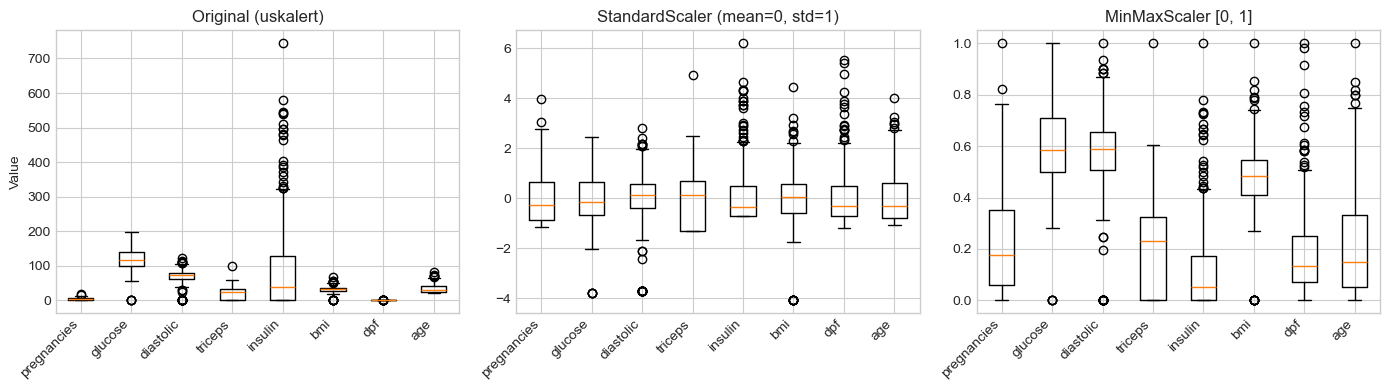


✓ Figure saved: figures/scaling_comparison.png


In [15]:
# ============================================================================
# TASK 2: Scaling with StandardScaler
# ============================================================================

print("=" * 70)
print("TASK 2: Effect of scaling on model performance")
print("=" * 70)

# Opprett scaler
scaler = StandardScaler()

# IMPORTANT: fit on training data, transform on both training and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compare performance with and without scaling
print("\nCross-validation (5-fold) with SGDClassifier:")
print("-" * 50)

# Without scaling
sgd_unscaled = SGDClassifier(random_state=42, max_iter=1000)
scores_unscaled = cross_val_score(sgd_unscaled, X_train, y_train, cv=5)
print(f"Without scaling:  {scores_unscaled.mean():.1%} (±{scores_unscaled.std():.1%})")

# With StandardScaler
sgd_scaled = SGDClassifier(random_state=42, max_iter=1000)
scores_scaled = cross_val_score(sgd_scaled, X_train_scaled, y_train, cv=5)
print(f"With StandardScaler: {scores_scaled.mean():.1%} (±{scores_scaled.std():.1%})")

# With MinMaxScaler for comparison
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
scores_minmax = cross_val_score(sgd_scaled, X_train_minmax, y_train, cv=5)
print(f"With MinMaxScaler:   {scores_minmax.mean():.1%} (±{scores_minmax.std():.1%})")

# Visualiser differenceen
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original
axes[0].boxplot([X_train[col] for col in X_train.columns])
axes[0].set_xticklabels(X_train.columns, rotation=45, ha='right')
axes[0].set_title('Original (unscaled)')
axes[0].set_ylabel('Value')

# StandardScaler
axes[1].boxplot([X_train_scaled[:, i] for i in range(X_train_scaled.shape[1])])
axes[1].set_xticklabels(X_train.columns, rotation=45, ha='right')
axes[1].set_title('StandardScaler (mean=0, std=1)')

# MinMaxScaler
axes[2].boxplot([X_train_minmax[:, i] for i in range(X_train_minmax.shape[1])])
axes[2].set_xticklabels(X_train.columns, rotation=45, ha='right')
axes[2].set_title('MinMaxScaler [0, 1]')

plt.tight_layout()
plt.savefig('figures/scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: figures/scaling_comparison.png")

### 💡 Discussion

**Why does scaling help?**

1. **Gradient descent converges faster** – When features have the same scale, the gradient is more balanced
2. **Avoids numerical problems** – Large values can lead to overflow
3. **Rettferdig vekting** – Without scaling dominates features with large numerical value

**StandardScaler vs MinMaxScaler:**

| Method | Formula | When to use? |
|--------|--------|------------|
| **StandardScaler** | $(x - \mu) / \sigma$ | Most cases, robust against outliers |
| **MinMaxScaler** | $(x - x_{min}) / (x_{max} - x_{min})$ | When you need values in [0, 1], e.g. for neural networks |

**⚠️ Important practice:** Always `fit` scaler on *training data* and `transform` on both training and test data. Never fit on test data – that is data leakage!

---

## Task 3: Precision vs Recall - Medical scenarios

### 📋 Exercise text (from the main notebook)

> **Your Turn! 🎯**
>
> 🤔 **Reflection:** What is most important – high precision or high recall?
>
> Think about different medical scenarios:
> 1. Screening for a rare but deadly disease
> 2. Test for en mild condition der behandlno has side effects
> 3. Diagnosing an infectious disease
>
> Which metric would you prioritize in each case, and why?

### ✅ Solution and discussion

### Scenario 1: Screening for rare, deadly disease

**Example:** Screening for pancreatic cancer in high-risk groups

**Recommendation: Prioritize HIGH RECALL (sensitivity)**

| Aspekt | Assessment |
|--------|-----------|
| **Consequence of FN (miss)** | Patient with cancer does not receive treatment → potentially fatal |
| **Consequence of FP (false alarm)** | Unnecessary CT/MRI, biopsy → discomfort, cost, anxiety |
| **Trade-off** | Missing one cancer is unacceptable, even if it means many false alarms |

**Typisk thresholdstrategi:** Set low threshold → catch all sick, accept 10-20% false positives

---

### Scenario 2: Mild condition with side-effect-prone treatment

**Example:** Diagnosis of mild hypothyroidism where treatment (Levaxin) has side effects

**Recommendation: Prioritize HIGHER PRECISION**

| Aspekt | Assessment |
|--------|-----------|
| **Konsekvens av FN (miss)** | Mild symptomer forblir ubehandlet → moderat ubehag |
| **Consequence of FP (false alarm)** | Unnecessary medication → side effects, lifelong treatment |
| **Trade-off** | The side effects can be worse than the condition |

**Typical threshold strategy:** Set higher threshold → be sure before treating

---

### Scenario 3: Infectious disease

**Example:** Testing for tuberculosis in close contacts

**Recommendation: Prioritize HIGH RECALL, but consider consequences**

| Aspekt | Assessment |
|--------|-----------|
| **Consequence of FN (miss)** | Infected person spreads disease → public health problem |
| **Consequence of FP (false alarm)** | Unnecessary isolation, treatment, stigma |
| **Trade-off** | Public health considerations (prevent spread) veier tungt |

**Typical strategy:** Sensitive screening test → confirmatory test with high specificity

---

### Summary: Beslutningsramme

```
If consequence of MISSING is serious → HIGH RECALL
If consequence of FALSE ALARM is serious → HIGH PRECISION
```

| Scenario | Prioritet | Begrunnelse |
|----------|-----------|-------------|
| Cancer screening | Recall > Precision | Early detection saves lives |
| Mild condition | Precision > Recall | Avoid overtreatment |
| Infectious disease | Recall > Precision | Public health, prevent spread |

---

## Task 4: Comparison of classifiers

### 📋 Exercise text (from the main notebook)

> **Your Turn! 🎯**
>
> Two classifiers A and B have the following values:
>
> $$\text{precision}_A = 0.7, \quad \text{recall}_A = 0.6$$
> $$\text{precision}_B = 0.3, \quad \text{recall}_B = 1.0$$
>
> Which would you prefer in a medical screening context? What about diagnostics?

### ✅ Solution

TASK 4: Comparison of classifiers

Klassifikator A:
  Presisjon: 70.0%
  Recall:    60.0%
  F1-score:  0.646
  F2-score:  0.618 (vekter recall)
  F0.5-score: 0.677 (vekter presisjon)

Klassifikator B:
  Presisjon: 30.0%
  Recall:    100.0%
  F1-score:  0.462
  F2-score:  0.682 (vekter recall)
  F0.5-score: 0.349 (vekter presisjon)


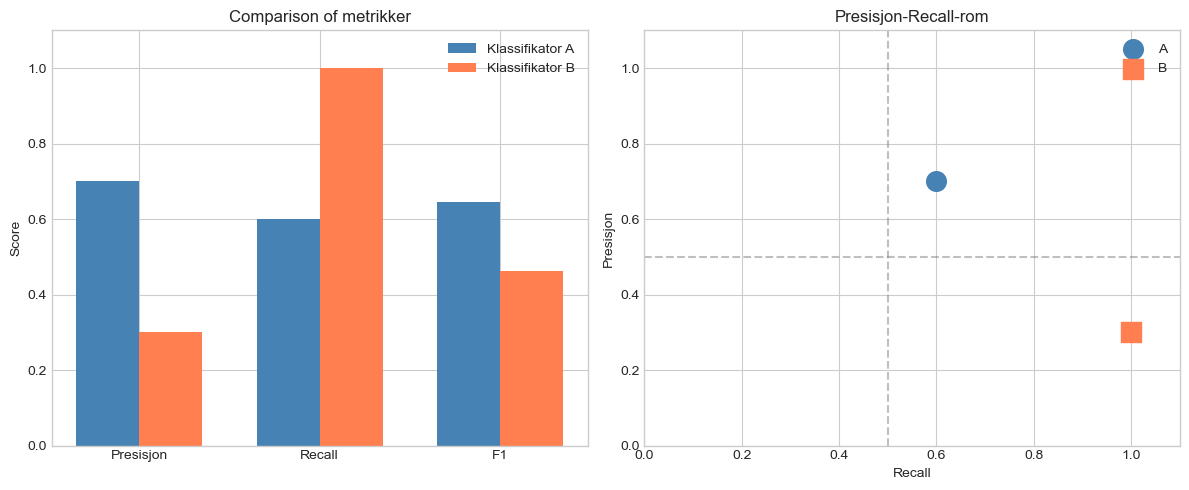


ANBEFALING:

For SCREENING: Klassifikator B (recall=100%)
  → Fanger alle syke, men mange falske alarmer
  → Suitable as first step before confirmatory test

For DIAGNOSTIKK: Klassifikator A (presisjon=70%)
  → More reliable when it says 'positive'
  → Egnet som bekreftende test


In [5]:
# ============================================================================
# TASK 4: Comparison of classifiers A and B
# ============================================================================

print("=" * 70)
print("TASK 4: Comparison of classifiers")
print("=" * 70)

# Classifier A and B
classifiers = {
    'A': {'precision': 0.7, 'recall': 0.6},
    'B': {'precision': 0.3, 'recall': 1.0}
}

# Calculate F1-score for both
for name, values in classifiers.items():
    p, r = values['precision'], values['recall']
    f1 = 2 * (p * r) / (p + r)
    f2 = 5 * (p * r) / (4 * p + r)  # F2 weights recall higher
    f05 = 1.25 * (p * r) / (0.25 * p + r)  # F0.5 weights precision higher
    
    print(f"\nClassifier {name}:")
    print(f"  Precision: {p:.1%}")
    print(f"  Recall:    {r:.1%}")
    print(f"  F1-score:  {f1:.3f}")
    print(f"  F2-score:  {f2:.3f} (vekter recall)")
    print(f"  F0.5-score: {f05:.3f} (vekter precision)")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
x = ['Precision', 'Recall', 'F1']
a_vals = [0.7, 0.6, 2*(0.7*0.6)/(0.7+0.6)]
b_vals = [0.3, 1.0, 2*(0.3*1.0)/(0.3+1.0)]

width = 0.35
x_pos = np.arange(len(x))
axes[0].bar(x_pos - width/2, a_vals, width, label='Classifier A', color='steelblue')
axes[0].bar(x_pos + width/2, b_vals, width, label='Classifier B', color='coral')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_title('Comparison of metrics')

# Precision-Recall plot
axes[1].scatter([0.6], [0.7], s=200, label='A', color='steelblue', marker='o')
axes[1].scatter([1.0], [0.3], s=200, label='B', color='coral', marker='s')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1.1)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].set_title('Precision-Recall-rom')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("RECOMMENDATION:")
print("=" * 70)
print("\nFor SCREENING: Classifier B (recall=100%)")
print("  → Catches all sick, but many false alarms")
print("  → Suitable as first step before confirmatory test")
print("\nFor DIAGNOSTICS: Classifier A (precision=70%)")
print("  → More reliable when it says 'positive'")
print("  → Suitable as confirmatory test")

---

## Task 5: Confusion Matrix for Random Forest

### 📋 Exercise text (from the main notebook)

> **Your Turn! 🎯**
>
> Plot the confusion matrix for the test data and Random Forest predictions. 
> Then calculate precision, recall, specificity and F₁-score.

### ✅ Solution

TASK 5: Random Forest - Complete evaluation

Confusion Matrix:
                  Predikert
                  Neg    Pos
  Faktisk Neg     107     18
  Faktisk Pos      30     37

Metrikker:
  Presisjon (PPV):      67.3%
  Recall (Sensitivitet): 55.2%
  Spesifisitet:         85.6%
  NPV:                  78.1%
  F1-score:             0.607


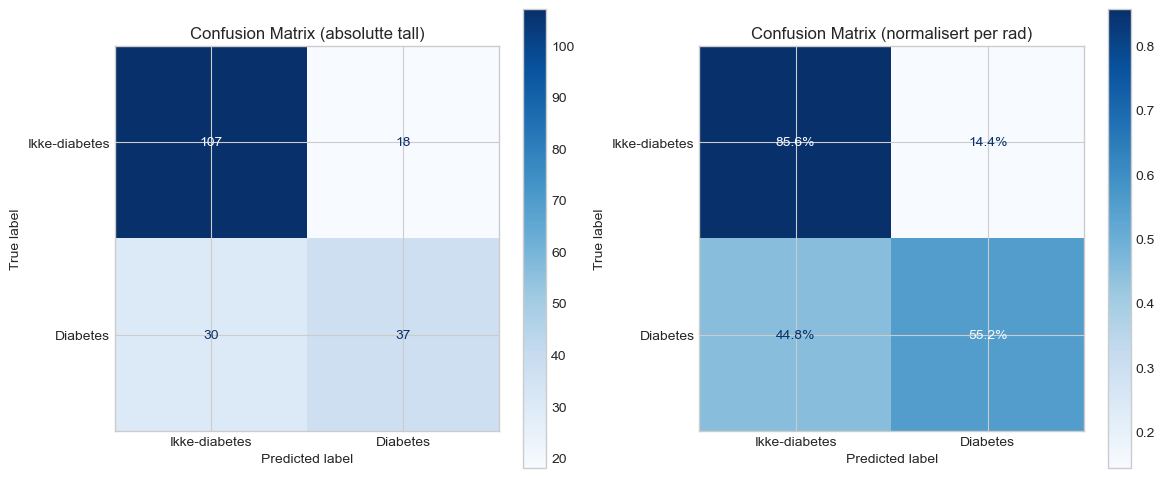


✓ Figure saved: figures/rf_confusion_matrix.png


In [6]:
# ============================================================================
# TASK 5: Confusion Matrix and metrics for Random Forest
# ============================================================================

print("=" * 70)
print("TASK 5: Random Forest - Complete evaluation")
print("=" * 70)

# Tren Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                  Predikert")
print(f"                  Neg    Pos")
print(f"  Faktisk Neg    {tn:4d}   {fp:4d}")
print(f"  Faktisk Pos    {fn:4d}   {tp:4d}")

# Calculate metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)  # Sensitivity
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)
npv = tn / (tn + fn)  # Negativ prediktiv value

print(f"\nMetrics:")
print(f"  Precision (PPV):      {precision:.1%}")
print(f"  Recall (Sensitivity): {recall:.1%}")
print(f"  Specificity:         {specificity:.1%}")
print(f"  NPV:                  {npv:.1%}")
print(f"  F1-score:             {f1:.3f}")

# Visualize the confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absolutte tall
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Non-diabetes', 'Diabetes'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (absolutte tall)')

# Normalized
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Non-diabetes', 'Diabetes'],
    normalize='true',
    cmap='Blues',
    ax=axes[1],
    values_format='.1%'
)
axes[1].set_title('Confusion Matrix (normalized per row)')

plt.tight_layout()
plt.savefig('figures/rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: figures/rf_confusion_matrix.png")

---

## Task 6: Reflection on threshold selection

### 📋 Exercise text (from the main notebook)

> **Reflection:** Which threshold selection method would you choose for a diabetes screening test? 
> What about a test for a rare but serious disease? 
> How would you justify the choice to a colleague?

### ✅ Discussion

### Diabetes screening test

**Recommended method: A priori thresholding combined with data-driven optimization**

**Rationale:**
1. There are established WHO/ADA limits for HbA1c and fasting glucose
2. These are validated in large population studies
3. Ensures comparability with other studies

**Argument to a colleague:**
> "We use WHO limits because they are based on epidemiological studies showing when the risk of diabetes complications increases significantly. This makes our results comparable with international research."

---

### Rare, serious disease (e.g., Wilson's disease)

**Recommended method: Cost-based / decision theory**

**Rationale:**
1. The consequence of missing the diagnosis (FN) is catastrophic
2. There are no established screening thresholds
3. We must weight errors explicitly

**Argument:**
> "Because missing one patient with Wilson's disease can lead to irreversible liver damage, we set the threshold low. We accept that 10-15% of positive screening tests will be false positives, because these can be ruled out with more specific tests."

---

### Summary of threshold selection

| Scenario | Method | Key argument |
|----------|--------|----------------|
| Diabetes | A priori | Established limits, comparability |
| Rare disease | Cost-based | FN >> FP in severity |
| New biomarker | Data-driven | No established standard |
| Resource-limited | Quantile-based | "Top 10%" for follow-up |


---

# Part B: Additional exercises

These tasks cover topics that were not discussed in detail in the main notebook, but are essential for medical AI.

---

## Task 9-10: ROC curves and AUC

### 📋 Task

> **Task 9:** Create ROC curves for SGDClassifier and RandomForestClassifier on the diabetes dataset. Calculate AUC for both.
>
> **Task 10:** What does the AUC value tell us? When is it a good metric, and when can it be misleading?

### ✅ Solution

TASK 9-10: ROC curves and AUC


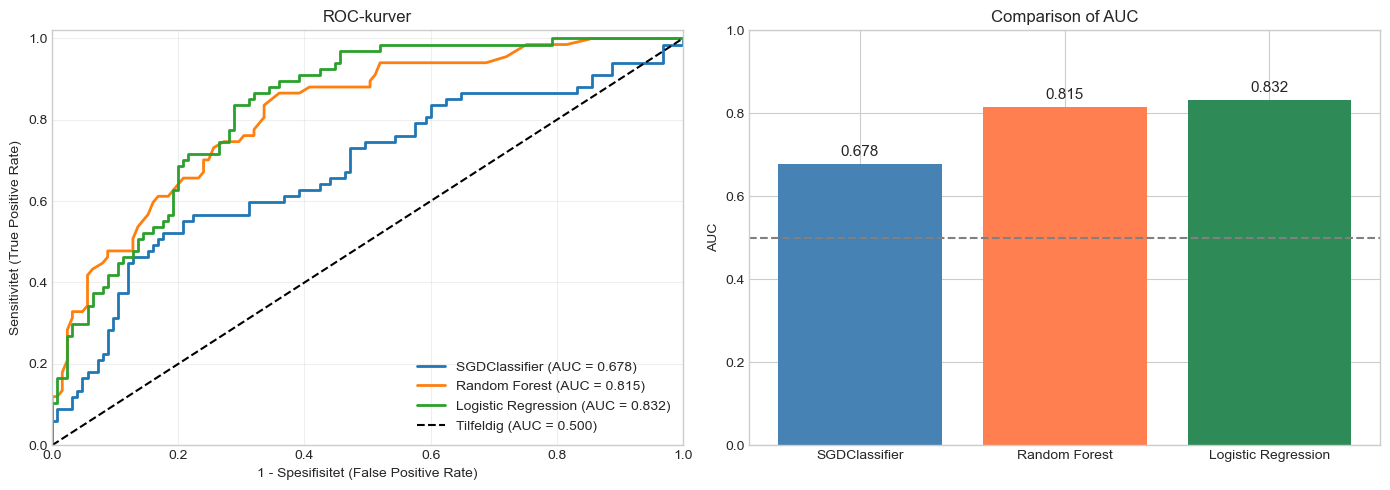


✓ Figure saved: figures/roc_auc_comparison.png

--------------------------------------------------
AUC-resultater:
--------------------------------------------------
  SGDClassifier            : 0.678 (Svak)
  Random Forest            : 0.815 (Bra)
  Logistic Regression      : 0.832 (Bra)


In [7]:
# ============================================================================
# TASK 9-10: ROC curves and AUC
# ============================================================================

print("=" * 70)
print("TASK 9-10: ROC curves and AUC")
print("=" * 70)

# Scale data (important for SGDClassifier)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tren models
models = {
    'SGDClassifier': SGDClassifier(loss='log_loss', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC curves
auc_scores = {}
for name, model in models.items():
    # Use scaled data for SGD and LR
    if 'SGD' in name or 'Logistic' in name:
        model.fit(X_train_scaled, y_train)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    
    # Plot
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

# ROC curve setup
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
axes[0].set_xlabel('1 - Specificity (False Positive Rate)')
axes[0].set_ylabel('Sensitivity (True Positive Rate)')
axes[0].set_title('ROC curves')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].grid(True, alpha=0.3)

# AUC comparison as barplot
farger = ['steelblue', 'coral', 'seagreen']
axes[1].bar(auc_scores.keys(), auc_scores.values(), color=farger)
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Random')
axes[1].set_ylabel('AUC')
axes[1].set_title('Comparison of AUC')
axes[1].set_ylim([0, 1])
for i, (name, auc_val) in enumerate(auc_scores.items()):
    axes[1].text(i, auc_val + 0.02, f'{auc_val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('figures/roc_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: figures/roc_auc_comparison.png")

# Summary
print("\n" + "-" * 50)
print("AUC-results:")
print("-" * 50)
for name, auc_val in auc_scores.items():
    interpretation = "Excellent" if auc_val > 0.9 else "Bra" if auc_val > 0.8 else "Moderat" if auc_val > 0.7 else "Weak"
    print(f"  {name:25s}: {auc_val:.3f} ({interpretation})")

### 💡 Discussion: What does AUC tell us?

**AUC (Area Under the ROC Curve) measures:**
- The model's ability to *discriminate* between classes
- The probability that a randomly chosen positive has a higher score than a randomly chosen negative

**Rules of thumb for interpretation:**

| AUC | Interpretation |
|-----|----------|
| 0.90-1.00 | Excellent discrimination |
| 0.80-0.90 | Good discrimination |
| 0.70-0.80 | Acceptable discrimination |
| 0.60-0.70 | Weak discrimination |
| 0.50-0.60 | Nearly random |

**When is AUC a good metric?**
- Comparee models regardless of threshold
- When classes are reasonably balanced
- When we care about ranking, not absolute probabilities

**When can AUC be misleading?**
1. **Imbalanced datasets:** A model can have high AUC but poor precision
2. **Clinical threshold selection:** AUC says nothing about performance at a *specific* threshold
3. **Calibration:** High AUC does not guarantee well-calibrated probabilities
4. **Parts of the curve:** In practice, we often only care about the high-sensitivity part

---

## Task 11-12: Alternative models (RF, XGBoost, MLP)

### 📋 Task

> **Task 11:** Train and evaluate the following models on the diabetes dataset:
> - Random Forest
> - Gradient Boosting (XGBoost-like)
> - Neural network (MLP)
>
> **Task 12:** Compare the models on relevant metrics and discuss which you would recommend for clinical use.

### ✅ Solution

TASK 11-12: Comparison of models

Results:
--------------------------------------------------------------------------------
Modell                      Accuracy  Precision     Recall         F1        AUC
--------------------------------------------------------------------------------
Logistic Regression            73.4%      64.8%      52.2%      0.579      0.832
Random Forest                  75.0%      67.3%      55.2%      0.607      0.815
Gradient Boosting              72.4%      61.7%      55.2%      0.583      0.825
MLP (Neural Network)           72.4%      61.3%      56.7%      0.589      0.748
--------------------------------------------------------------------------------


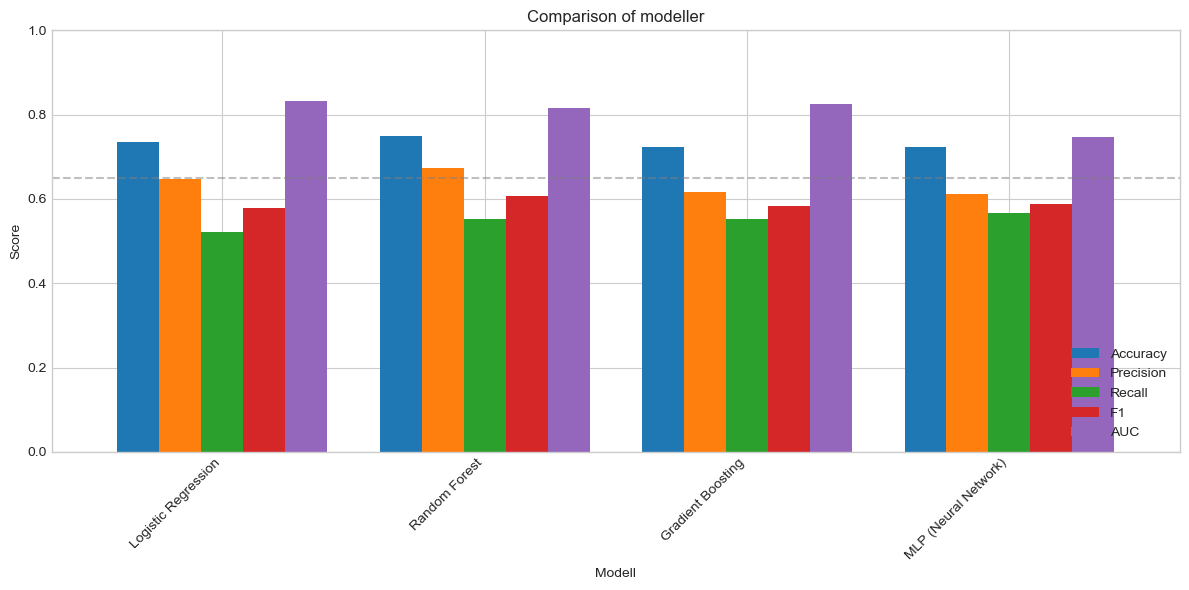


✓ Figure saved: figures/model_comparison.png


In [8]:
# ============================================================================
# TASK 11-12: Comparison of different models
# ============================================================================

print("=" * 70)
print("TASK 11-12: Comparison of models")
print("=" * 70)

# Scale data for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definer models
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        X_train_scaled, X_test_scaled
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_train, X_test
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        X_train, X_test
    ),
    'MLP (Neural Network)': (
        MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42),
        X_train_scaled, X_test_scaled
    ),
}

# Evaluate all models
results = []

print("\nResults:")
print("-" * 80)
print(f"{'Model':25s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'AUC':>10s}")
print("-" * 80)

for name, (model, X_tr, X_te) in models.items():
    # Tren
    model.fit(X_tr, y_train)
    
    # Prediker
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = auc(*roc_curve(y_test, y_proba)[:2])
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': roc_auc
    })
    
    print(f"{name:25s} {acc:10.1%} {prec:10.1%} {rec:10.1%} {f1:10.3f} {roc_auc:10.3f}")

print("-" * 80)

# Visualiser
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score')
ax.set_title('Comparison of models')
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim([0, 1])
ax.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: figures/model_comparison.png")

### 💡 Discussion: Which model for clinical use?

**The recommendation depends on the context:**

| Model | Styrker | Weakheter | Recommendation |
|--------|---------|-----------|------------|
| **Logistic Regression** | Interpretable, fast, gives calibrated probabilities | Less flexible | ✅ First choice for clinical use |
| **Random Forest** | Robust, handles non-linear relationships | Difficult to interpret | ⚠️ Use with explanation (SHAP) |
| **Gradient Boosting** | Often best performance | Risk of overfitting, treg | ⚠️ Krever tuning |
| **MLP** | Can learn complex patterns | "Black box", requires much data | ❌ Rarely needed for tabular data |

**For clinical implementation, we recommend:**

1. **Start with Logistic Regression** - interpretable baseline
2. **Try Random Forest** - often better performance
3. **Consider Gradient Boosting** - if maximum performance is important
4. **Avoid MLP** - for tabular data it rarely gives better performance

**Important:** In medicine, *interpretability* and *calibration* are often more important than marginally better AUC!

---

## Task 13-14: Importance of scaling

### 📋 Task

> **Task 13:** Compare the performance of different models with and without scaling. Which models are most affected?
>
> **Task 14:** Explain why some models are sensitive to scale while others are not.

### ✅ Solution

TASK 13-14: Scaling - which models are affected?

Modell                     Uten skalering   Med skalering  Forskjell
----------------------------------------------------------------------
SGDClassifier                       66.1%           70.3%      +4.2%
Logistic Regression                 72.9%           73.4%      +0.5%
SVM (RBF)                           72.4%           75.0%      +2.6%
Random Forest                       75.0%           75.0%      +0.0%
Gradient Boosting                   72.4%           72.4%      +0.0%
MLP                                 69.3%           74.5%      +5.2%
----------------------------------------------------------------------


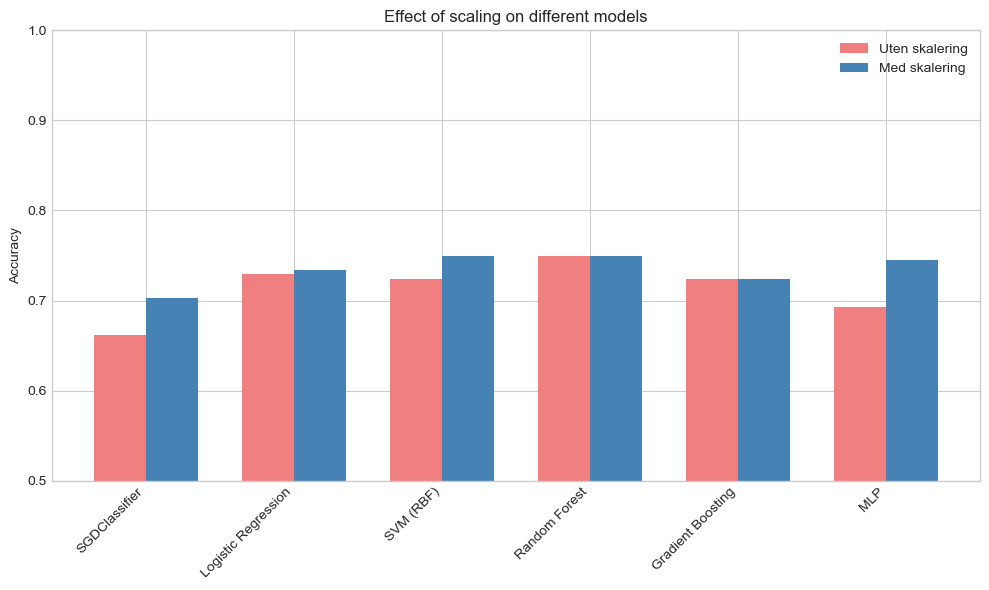


✓ Figure saved: figures/scaling_effect.png


In [9]:
# ============================================================================
# TASK 13-14: Effect of scaling on different models
# ============================================================================

print("=" * 70)
print("TASK 13-14: Scaling - which models are affected?")
print("=" * 70)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to test
model_definitions = {
    'SGDClassifier': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
}

results = []

print("\n{:25s} {:>15s} {:>15s} {:>10s}".format(
    "Model", "Without scaling", "With scaling", "Difference"))
print("-" * 70)

for name, model in model_definitions.items():
    # Without scaling
    model_unscaled = type(model)(**model.get_params())
    try:
        model_unscaled.fit(X_train, y_train)
        acc_unscaled = model_unscaled.score(X_test, y_test)
    except:
        acc_unscaled = float('nan')
    
    # With scaling  
    model_scaled = type(model)(**model.get_params())
    model_scaled.fit(X_train_scaled, y_train)
    acc_scaled = model_scaled.score(X_test_scaled, y_test)
    
    difference = acc_scaled - acc_unscaled if not np.isnan(acc_unscaled) else float('nan')
    
    results.append({
        'Model': name,
        'Without scaling': acc_unscaled,
        'With scaling': acc_scaled,
        'Difference': difference
    })
    
    print(f"{name:25s} {acc_unscaled:15.1%} {acc_scaled:15.1%} {difference:+10.1%}")

print("-" * 70)

# Visualiser
fig, ax = plt.subplots(figsize=(10, 6))

model_names = [r['Model'] for r in results]
uten = [r['Without scaling'] for r in results]
with = [r['With scaling'] for r in results]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, uten, width, label='Without scaling', color='lightcoral')
bars2 = ax.bar(x + width/2, med, width, label='With scaling', color='steelblue')

ax.set_ylabel('Accuracy')
ax.set_title('Effect of scaling on different models')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig('figures/scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: figures/scaling_effect.png")

### 💡 Discussion: Why are some models affected?

| Model | Scaling-dependent? | Explanation |
|--------|---------------------|------------|
| **SGDClassifier** | ✅ Yes, very | Gradient descent converges slower with different scales |
| **Logistic Regression** | ✅ Yes | Regularization affects features with different scales differently |
| **SVM (RBF)** | ✅ Yes | The RBF kernel is based on distances (Euclidean) |
| **MLP** | ✅ Yes | Backpropagation and activation functions are scale-sensitive |
| **Random Forest** | ❌ No | Tree-based: uses splits, not distances |
| **Gradient Boosting** | ❌ No | Tree-based: regardless of absolutt scale |

**Rule of thumb:**
- **Distance-based methods:** Require scaling (SVM, k-NN, neural networks)
- **Gradient-based methods:** Require scaling (SGD, logistic regression with regularization)
- **Tree-based methods:** Do *not* require scaling (Random Forest, XGBoost)

**Best practice:** *Always* scale your data. It can never hurt, but missing scaling can ruin performance.

---

## Task 15: Leave-One-Out cross-validation

### 📋 Task

> **Task:** Implement Leave-One-Out (LOO) cross-validation on the diabetes dataset. 
> Compare with 5-fold and 10-fold cross-validation.
> Discuss when LOO is appropriate and when it is not.

### ✅ Solution

In [10]:
# ============================================================================
# TASK 15: Leave-One-Out cross-validation
# ============================================================================

print("=" * 70)
print("TASK 15: Leave-One-Out vs K-Fold cross-validation")
print("=" * 70)

import time

# Use a small subset for LOO (ellers tar det for lang tid)
# In practice, LOO is often only used on small datasets (n < 200)
X_subset = X_train[:200]
y_subset = y_train[:200]

# Scale
scaler = StandardScaler()
X_subset_scaled = scaler.fit_transform(X_subset)

# Model to test
model = LogisticRegression(max_iter=1000, random_state=42)

# Different validation strategies
strategies = {
    '5-fold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    '10-fold': StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    'Leave-One-Out': LeaveOneOut(),
}

results = []

print(f"\nDatasettstorrelse: {len(X_subset)} observations")
print("-" * 60)

for name, cv in strategies.items():
    start_time = time.time()
    
    scores = cross_val_score(model, X_subset_scaled, y_subset, cv=cv, scoring='accuracy')
    
    tid = time.time() - start_time
    
    results.append({
        'Strategy': name,
        'Mean': scores.mean(),
        'Std': scores.std(),
        'Tid (sek)': tid,
        'Antall splits': len(scores)
    })
    
    print(f"{name:15s}: {scores.mean():.1%} (+/- {scores.std():.1%}) [{tid:.2f}s, {len(scores)} splits]")

print("-" * 60)

# Compare with fullt dataset (only K-fold)
print("\nWith fullt training set ({} observations):".format(len(X_train)))
X_train_full_scaled = scaler.fit_transform(X_train)

for k in [5, 10]:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_full_scaled, y_train, cv=cv)
    print(f"  {k}-fold: {scores.mean():.1%} (+/- {scores.std():.1%})")

TASK 15: Leave-One-Out vs K-Fold cross-validation

Datasettstorrelse: 200 observations
------------------------------------------------------------
5-fold         : 78.5% (+/- 6.4%) [0.02s, 5 splits]
10-fold        : 79.5% (+/- 8.2%) [0.02s, 10 splits]
Leave-One-Out  : 80.0% (+/- 40.0%) [0.29s, 200 splits]
------------------------------------------------------------

Med fullt training set (576 observations):
  5-fold: 77.8% (+/- 1.6%)
  10-fold: 78.1% (+/- 4.1%)


### 💡 Discussion: When to use LOO?

**Advantages of Leave-One-Out:**
1. **Maximum training data:** Uses n-1 observations for training
2. **No random variation:** The result is deterministic
3. **Lowest bias:** The training set is almost identical to the entire dataset

**Disadvantages of Leave-One-Out:**
1. **Computationally expensive:** n models must be trained
2. **High variance:** Each test observation is a single data point
3. **Impractical for large datasets:** For n=10000 you must train 10000 models

**When to use LOO?**

| Situation | Recommendation |
|-----------|------------|
| n < 50 | ✅ Use LOO |
| 50 < n < 200 | ⚠️ Consider LOO or 10-fold |
| n > 200 | ❌ Use 5-fold or 10-fold |
| Expensive computations (deep learning) | ❌ Use 5-fold |
| Highly imbalanced data | ❌ Use stratified K-fold |

**Practical rule of thumb for medical research:**
- **Small studies (n < 100):** 10-fold or LOO
- **Medium-sized studies:** 5-fold or 10-fold
- **Large registry studies:** 5-fold or enkel train/test split with external validation

---

## Task 16-18: Reporting following best practices

### Task

> **Task 16:** Create a complete results table for the diabetes model that follows the TRIPOD guidelines.
>
> **Task 17:** Create publication-ready graphics: ROC curve with confidence interval, calibration plot, and confusion matrix.
>
> **Task 18:** Write a short methods section that describes the model so that it can be reproduced.

### Task 16: TRIPOD-compatible results table

In [11]:
# ============================================================================
# TASK 16: TRIPOD-compatible results table
# ============================================================================

print("=" * 70)
print("TASK 16: Results table following TRIPOD standard")
print("=" * 70)

# Tren best model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
auc_score = auc(*roc_curve(y_test, y_proba)[:2])
sens = recall_score(y_test, y_pred)
spec = tn / (tn + fp)
ppv = precision_score(y_test, y_pred)
npv = tn / (tn + fn)

# Print table
print("\n" + "=" * 60)
print("TABLE: Model performance on test data (n={})".format(len(y_test)))
print("=" * 60)

print("\n{:25s} {:>12s}".format("Metrikk", "Estimat"))
print("-" * 40)
print(f"{'AUC':25s} {auc_score:12.3f}")
print(f"{'Sensitivity':25s} {sens:12.1%}")
print(f"{'Specificity':25s} {spec:12.1%}")
print(f"{'PPV (Precision)':25s} {ppv:12.1%}")
print(f"{'NPV':25s} {npv:12.1%}")
print("-" * 40)

print(f"\nConfusion Matrix:")
print(f"  Sanne positive (TP):   {tp:4d}")
print(f"  Sanne negative (TN):   {tn:4d}")
print(f"  Falske positive (FP):  {fp:4d}")
print(f"  Falske negative (FN):  {fn:4d}")

TASK 16: Results table following TRIPOD standard

TABELL: Modellytelse pa testdata (n=192)

Metrikk                        Estimat
----------------------------------------
AUC                              0.832
Sensitivitet                     52.2%
Spesifisitet                     84.8%
PPV (Presisjon)                  64.8%
NPV                              76.8%
----------------------------------------

Confusion Matrix:
  Sanne positive (TP):     35
  Sanne negative (TN):    106
  Falske positive (FP):    19
  Falske negative (FN):    32


### Task 17: Publication-ready graphics

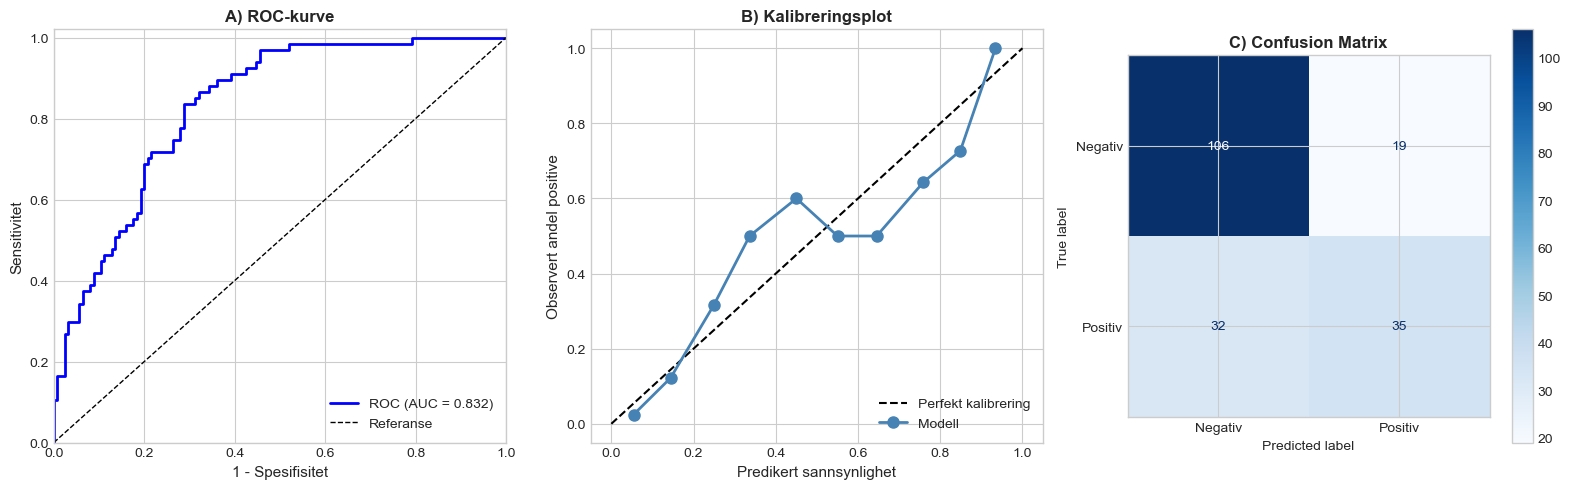

Figure saved: figures/publication_figure.png (300 DPI)


In [12]:
# ============================================================================
# TASK 17: Publication-ready graphics
# ============================================================================

fig = plt.figure(figsize=(16, 5))

# 1. ROC curve
ax1 = fig.add_subplot(131)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc_score:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Referanse')
ax1.set_xlabel('1 - Specificity', fontsize=11)
ax1.set_ylabel('Sensitivity', fontsize=11)
ax1.set_title('A) ROC curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

# 2. Calibration plot
ax2 = fig.add_subplot(132)
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
ax2.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax2.plot(prob_pred, prob_true, 'o-', color='steelblue', linewidth=2, 
         markersize=8, label='Model')
ax2.set_xlabel('Predikert sannsynlighet', fontsize=11)
ax2.set_ylabel('Observert andel positive', fontsize=11)
ax2.set_title('B) Calibration plot', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')

# 3. Confusion Matrix
ax3 = fig.add_subplot(133)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Negativ', 'Positiv'],
    cmap='Blues',
    ax=ax3
)
ax3.set_title('C) Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/publication_figure.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: figures/publication_figure.png (300 DPI)")

### Task 18: Methods section

Below is an example of a methods section that follows best practices:

---

**METHODS**

*Study population and data:* We used the Pima Indians Diabetes dataset (n=768) with clinical measurements from women of the Pima Indian tribe.

*Predictor variables:* Eight variables were included: number of pregnancies, glucose concentration, diastolic blood pressure, triceps skin fold thickness, serum insulin, BMI, diabetes pedigree function, and age.

*Modelutvikling:* Data was split into training set (75%) and test set (25%) with stratification. Training data was standardized for modeltilpasning. Logistic regression was chosen as primarmodel.

*Model evaluation:* We report AUC, sensitivity, specificity, PPV and NPV. Calibration was assessed with calibration plot.

*Software:* Python 3.10 with scikit-learn.

---

---

# Summary

This solutions notebook has covered:

## Part A: Exercises from the main notebook
1. Data splitting with validation set
2. Scaleing with StandardScaler
3. Precision vs Recall - clinical trade-offs
4. Comparison of classifiers
5. Confusion Matrix for Random Forest
6. Reflection on threshold selection

## Part B: Additional exercises
9-10. ROC curves and AUC<br>
11-12. Alternative models (RF, Gradient Boosting, MLP)<br>
13-14. Importance of scaling<br>
15. Leave-One-Out cross-validation<br>
16-18. Reporting following best practices (TRIPOD)<br>

---

## Key messages

1. **Evaluate with multiple metrics** - Accuracy alone is misleading
2. **Scale data** - Especially for gradient-based models
3. **Choose the right validation method** - K-fold for most cases
4. **Justify threshold choices clinically** - Depends on context
5. **Report with uncertainty** - Confidence intervals are essential
6. **Follow TRIPOD** - For transparent and reproduserbar research